In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import ants
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import traceback

In [ ]:
import marimo as mo

os.chdir(mo.notebook_dir()) #Jupyterlab-like, change path to where the notebook is, all paths relative to this

In [ ]:
import deepcor

In [ ]:
# Check GPU details
deepcor.utils.check_gpu_and_speedup(tensor_size=(1000,1000), n_iter=100)

In [ ]:
# ModelConfig: Configure the model architecture
model_config = deepcor.ModelConfig(
    latent_dims=(8, 8),  # (shared dim, specific dim)
    beta=0.01,           # KLD loss weight
    gamma=0.0,           # TC loss weight
    delta=0.0,           # RONI zero constraint weight
    scale_MSE_GM=1e3,    # Gray matter reconstruction loss scale
    scale_MSE_CF=1e3,    # Non-gray matter reconstruction loss scale
    scale_MSE_FG=0.0,    # Foreground reconstruction loss scale
    do_disentangle=True  # Enable disentanglement
)


# TrainingConfig: Configure training parameters
training_config = deepcor.TrainingConfig(
    n_epochs=100,
    batch_size=1024,
    learning_rate=0.001,
    optimizer='adamw',
    betas=(0.9, 0.999),
    eps=1e-08,
    max_grad_norm=5.0,
    n_repetitions=10  # Number of ensemble repetitions
)


# DataConfig: Configure data preprocessing
data_config = deepcor.DataConfig(
    n_dummy_scans=0,
    apply_censoring=False,
    censoring_threshold=0.0,
    confound_columns=['X', 'Y', 'Z', 'RotX', 'RotY', 'RotZ']
)

# Create a complete configuration
config = deepcor.DeepCorConfig(
    model=model_config,
    training=training_config,
    data=data_config
)


print(model_config);print('\n')
print(training_config);print('\n')
print(data_config);print('\n')
print(config);print('\n')

ModelConfig(latent_dims=(8, 8), hidden_dims=None, beta=0.01, gamma=0.0, delta=0.0, scale_MSE_GM=1000.0, scale_MSE_CF=1000.0, scale_MSE_FG=0.0, do_disentangle=True)


TrainingConfig(n_epochs=5, batch_size=1024, learning_rate=0.001, optimizer='adamw', betas=(0.9, 0.999), eps=1e-08, max_grad_norm=5.0, n_repetitions=5)


DataConfig(n_dummy_scans=0, apply_censoring=False, censoring_threshold=0.0, also_nearby_voxels=True, confound_columns=['X', 'Y', 'Z', 'RotX', 'RotY', 'RotZ'])


DeepCorConfig(model=ModelConfig(latent_dims=(8, 8), hidden_dims=None, beta=0.01, gamma=0.0, delta=0.0, scale_MSE_GM=1000.0, scale_MSE_CF=1000.0, scale_MSE_FG=0.0, do_disentangle=True), training=TrainingConfig(n_epochs=5, batch_size=1024, learning_rate=0.001, optimizer='adamw', betas=(0.9, 0.999), eps=1e-08, max_grad_norm=5.0, n_repetitions=5), data=DataConfig(n_dummy_scans=0, apply_censoring=False, censoring_threshold=0.0, also_nearby_voxels=True, confound_columns=['X', 'Y', 'Z', 'RotX', 'RotY', 'RotZ']))




In [ ]:
# Define Data Paths
# Cell Tagged parameters for papermill looping

bids_path = '../Data/fMRI-Data/studyforrest-fmriprep/'

subs = [sub for sub in os.listdir(os.path.join(bids_path)) if sub.startswith('sub-')]
subs.sort()

session = 'ses-localizer'
task = 'objectcategories'
space = 'MNI152NLin2009cAsym'

analysis_name = 'test-advanced'

In [ ]:
cli_args = mo.cli_args()
if cli_args:
    print('script mode')
    s = int(cli_args['s'])
    r = int(cli_args['r'])
else:
    print('interactive mode')
    s = 0
    r = 4

interactive mode


In [ ]:
sub_id = subs[s]
run = str(r)

print(sub_id)
print(run)
print(analysis_name)

sub-01
4
test-advanced


In [ ]:
base = os.path.join(bids_path,sub_id,session)

# EPI
epi_path = os.path.join(base,'func',f'{sub_id}_{session}_task-{task}_run-{run}_bold_space-{space}_preproc.nii.gz')

# Confounds
confounds_path = os.path.join(base,'func',f'{sub_id}_{session}_task-{task}_run-{run}_bold_confounds.tsv')

gm_mask_path = os.path.join(bids_path,'mask_roi.nii')
cf_mask_path = os.path.join(bids_path,'mask_roni.nii')

assert os.path.exists(epi_path), 'epi_path does not exist'
assert os.path.exists(confounds_path), 'confounds_path does not exist'
assert os.path.exists(gm_mask_path), 'gm_mask_path does not exist'
assert os.path.exists(cf_mask_path), 'cf_mask_path does not exist'

os.makedirs(os.path.join('../Data/DeepCor-Outputs',analysis_name), exist_ok=True)

output_dir = os.path.join('../Data/DeepCor-Outputs',analysis_name,f'DeepCor-Forrest-S{s}-R{r}-cvae_v2')
deepcor.utils.io.safe_mkdir(output_dir)

print("EPI:", epi_path)
print("Confounds:", confounds_path)
print("output_dir:", output_dir)

EPI: ../Data/fMRI-Data/studyforrest-fmriprep/sub-01/ses-localizer/func/sub-01_ses-localizer_task-objectcategories_run-4_bold_space-MNI152NLin2009cAsym_preproc.nii.gz
Confounds: ../Data/fMRI-Data/studyforrest-fmriprep/sub-01/ses-localizer/func/sub-01_ses-localizer_task-objectcategories_run-4_bold_confounds.tsv
output_dir: ../Data/DeepCor-Outputs/test-advanced/DeepCor-Forrest-S0-R4-cvae_v2


In [ ]:
config.data.output_dir = output_dir
config.data.subject_idx = s
config.data.run_idx = r

In [ ]:
epi = ants.image_read(epi_path)
gm = ants.image_read(gm_mask_path)
cf = ants.image_read(cf_mask_path)

obs_list, noi_list, gm, cf = deepcor.data.get_obs_noi_list_coords(epi, gm, cf)

obs_list_coords.shape: (41147, 4, 156)
noi_list_coords.shape: (9105, 4, 156)
upsampling noi_list_coords
obs_list_coords.shape: (41147, 4, 156)
noi_list_coords.shape: (41147, 4, 156)


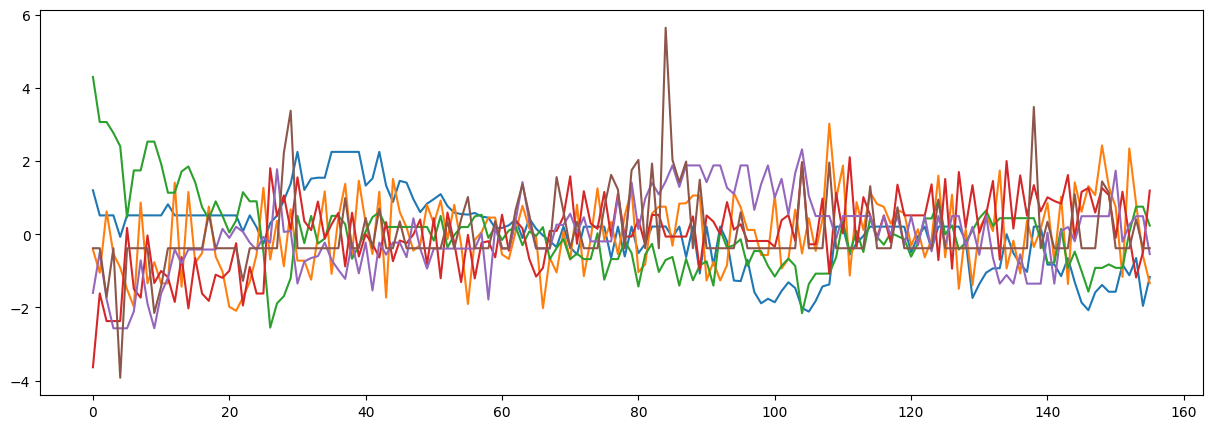

In [ ]:
conf = deepcor.data.get_confounds(confounds_path,norm='zscore')
plt.figure(figsize=(15,5))
plt.plot(conf.transpose())

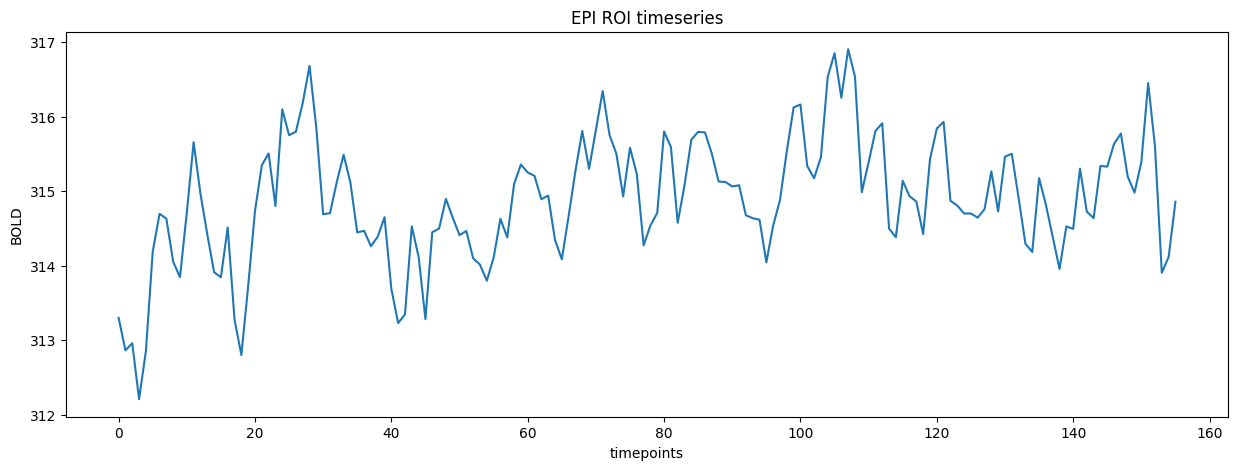

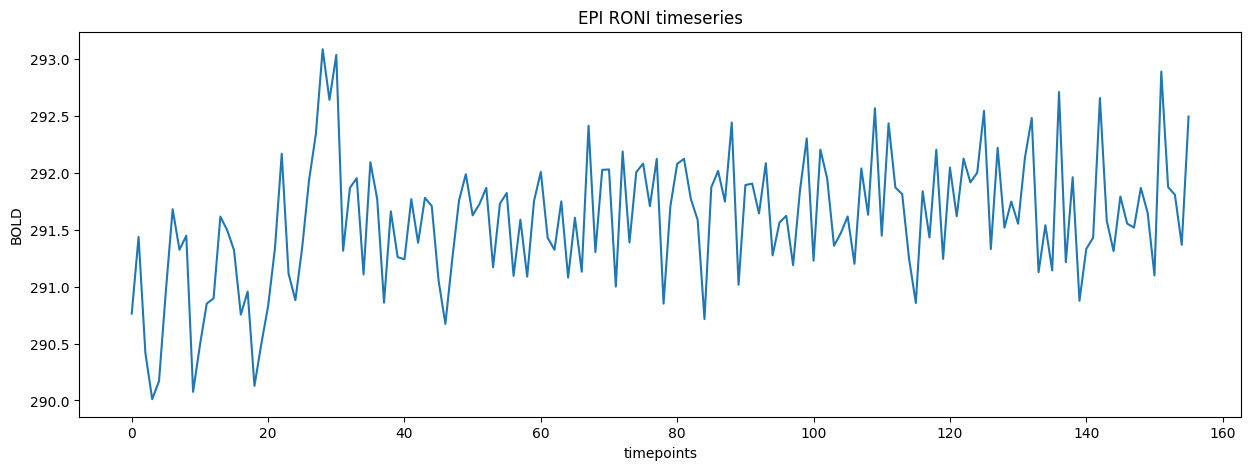

In [ ]:
deepcor.data.plot_timeseries(epi,gm,cf)

In [ ]:
# Create DataLoader 
train_dataset = deepcor.data.TrainDataset(obs_list, noi_list)
train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=config.training.batch_size, 
    shuffle=True, 
    drop_last=True)

In [ ]:
in_dim = obs_list.shape[-1]
in_channels = obs_list.shape[-2]
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
conf_torch = torch.tensor(np.array([conf for _ in range(training_config.batch_size)]))

def init_model(config):
    model = deepcor.models.CVAE(
        conf=conf_torch,
        in_channels=in_channels,
        in_dim=in_dim,
        latent_dim=config.model.latent_dims,
        beta=config.model.beta,
        gamma=config.model.gamma,
        delta=config.model.delta,
        scale_MSE_GM = config.model.scale_MSE_GM,
        scale_MSE_CF = config.model.scale_MSE_CF,
        scale_MSE_FG = config.model.scale_MSE_FG)

    model = model.to(device)
    return model

def init_trainer(model,config):
    trainer = deepcor.training.Trainer(
        model,
        device=device,
        optimizer_type=config.training.optimizer,
        lr=config.training.learning_rate,
        betas=config.training.betas,
        eps=config.training.eps,
        max_grad_norm=config.training.max_grad_norm
    )

    return trainer

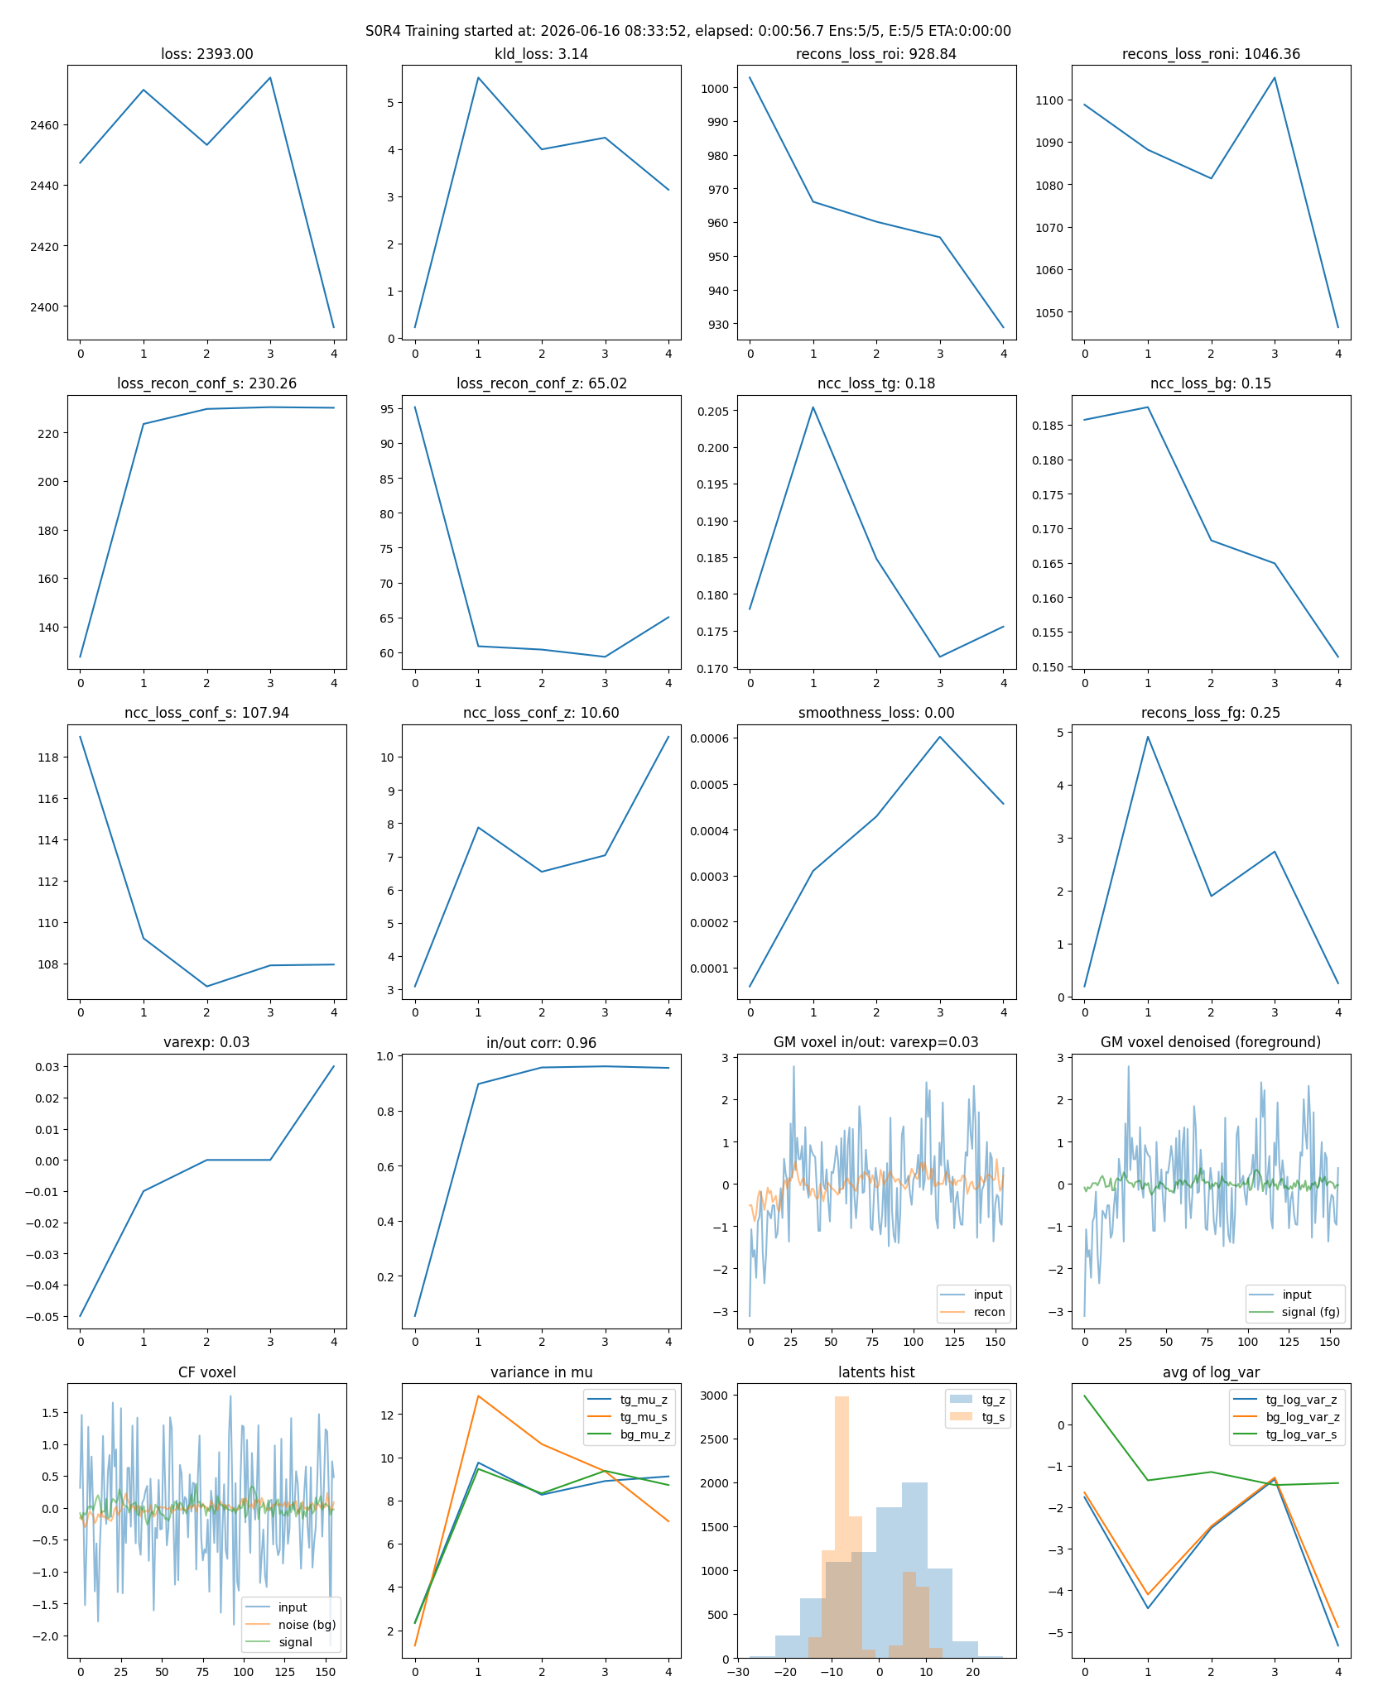

In [ ]:
for ensemble in range(config.training.n_repetitions):
    try:
        config.training.current_ensemble = ensemble
        track = deepcor.visualization.init_track('V2')
        loss_history = []

        model = init_model(config)
        trainer = init_trainer(model,config)

        for epoch in range(config.training.n_epochs):
            config.training.current_epoch = epoch
            # Train one epoch
            avg_loss = trainer.train_epoch(train_loader)
            loss_history.append(avg_loss)

            deepcor.visualization.update_track(track,train_loader,model,config)

            plt.close()
            fig = deepcor.visualization.show_dahsboard_v2_marimo(track)
            #mo.output.replace(fig)   # replace previous plot with the new one
            mo.output.replace_at_index(fig,0)
            #plt.close(fig)           # avoid duplicate/static matplotlib display

        # Save outputs
        #print("Saving model and results...")
        # Save checkpoint
        trainer.save_checkpoint(
            os.path.join(output_dir, f'model_final_ens{ensemble}.pt'), 
            config.training.n_epochs, 
            avg_loss)

        # Save track
        deepcor.visualization.save_track(os.path.join(output_dir, f'track_S{s}_R{r}_rep_{ensemble}.pickle'), track)

        deepcor.save_brain_signals(model,train_dataset,epi,gm,ofn=os.path.join(output_dir,f'signal_S{s}_R{r}_rep_{ensemble}.nii.gz'),batch_size=512,kind='FG')
        deepcor.save_brain_signals(model,train_dataset,epi,gm,ofn=os.path.join(output_dir,f'recon_S{s}_R{r}_rep_{ensemble}.nii.gz'),batch_size=512,kind='TG') # Optional
        deepcor.save_brain_signals(model,train_dataset,epi,gm,ofn=os.path.join(output_dir,f'noise_S{s}_R{r}_rep_{ensemble}.nii.gz'),batch_size=512,kind='BG') # Optional
    except Exception as e:
        print(f'error on ensemble {ensemble}, epoch {config.training.current_epoch}, skipping')
        print(f'Actual error: {repr(e)}')
        traceback.print_exc()

In [ ]:
# Once training is finished
signal_files = [os.path.join(output_dir,f) for f in os.listdir(output_dir) if all((f.startswith(f'signal_S{s}_R{r}_rep_'),f.endswith('.nii.gz')))]
track_files = [os.path.join(output_dir,f) for f in os.listdir(output_dir) if all((f.startswith(f'track_S{s}_R{r}_rep_'),f.endswith('.pickle')))]
signal_files.sort()
track_files.sort()
print('Ensemble of {} repetitions'.format(len(signal_files)))

Ensemble of 5 repetitions


In [ ]:
# Ensembling: Average the individual denoised files
signals_averaged = deepcor.average_signal_ensemble(signal_files,os.path.join(output_dir,f'signal_S{s}_R{r}_avg.nii.gz'))

# Save a copy of the Nodenoised
deepcor.data.array_to_brain(obs_list[:,0,:],epi,gm,os.path.join(output_dir,f'preproc_S{s}_R{r}.nii.gz'),inv_z_score=True,return_img=False)

# Save the CompCor version
compcor = deepcor.calc_and_save_compcor(epi,gm,cf,os.path.join(output_dir,f'compcor_S{s}_R{r}.nii.gz'),n_components=5,return_img=True)

100%|████████████████████████████████████████████████████████████████████████████████| 5/5 [00:06<00:00,  1.24s/it]


signals averaged: 5


In [ ]:
run_post_analyses = True # Whether to run contrast and correlation analyses

if run_post_analyses:
  events_fn = os.path.join(f'../Data/study-forrest-events/{sub_id}_ses-localizer_task-objectcategories_run-{r}_events.tsv')

  X1 = deepcor.get_design_matrix(epi,events_fn)
  X1

# If no post-training analyses needed, leave these empty
contrast_analyses = [] # Runs a voxelvise GLM and contrast analyses based on spec below
correlation_analyses = [] # Correlates each voxel with a specific target regressor

if run_post_analyses==True:
  correlation_analyses.append(
      {'corr_target' : X1['face'].values, # Correlate each voxel with this regressor
      'filename' : os.path.join(output_dir,f'corr2face_S{s}_R{r}.nii.gz'), # Output filename
      'plot' : True, # Automatically plot? If so specify a ROI
      'ROI' : f'../Data/study-forrest-ROIs/rFFA_final_mask_{sub_id}_bin.nii.gz'}) # ROI for plotting (Can be None)


  correlation_analyses.append(
      {'corr_target' : X1[['house','scene']].values.mean(axis=1),
      'filename' : os.path.join(output_dir,f'corr2place_S{s}_R{r}.nii.gz'),
      'plot' : True,
      'ROI' : f'../Data/study-forrest-ROIs/rPPA_final_mask_{sub_id}_bin.nii.gz'})

  contrast_analyses.append(
      {'contrast_vec' : [-1,5,-1,-1,-1,-1,0,0,0,0], # Contrast Vector spec
      'design_matrix' : X1,
      'filename' : os.path.join(output_dir,f'contrast_face_{s}_R{r}.nii.gz'),
      'plot' : True,
      'ROI' : f'../Data/study-forrest-ROIs/rFFA_final_mask_{sub_id}_bin.nii.gz'})

  contrast_analyses.append(
      {'contrast_vec' : [-1,-1,2,-1,2,-1,0,0,0,0],
      'design_matrix' : X1,
      'filename' : os.path.join(output_dir,f'contrast_place_S{s}_R{r}.nii.gz'),
      'plot' : True,
      'ROI' : f'../Data/study-forrest-ROIs/rPPA_final_mask_{sub_id}_bin.nii.gz'})

saved as: ../Data/DeepCor-Outputs/test-advanced/DeepCor-Forrest-S0-R4-cvae_v2/corr2face_S0_R4_preproc.nii.gz
saved as: ../Data/DeepCor-Outputs/test-advanced/DeepCor-Forrest-S0-R4-cvae_v2/corr2face_S0_R4_compcor.nii.gz
saved as: ../Data/DeepCor-Outputs/test-advanced/DeepCor-Forrest-S0-R4-cvae_v2/corr2face_S0_R4_deepcor.nii.gz
saved as: ../Data/DeepCor-Outputs/test-advanced/DeepCor-Forrest-S0-R4-cvae_v2/corr2place_S0_R4_preproc.nii.gz
saved as: ../Data/DeepCor-Outputs/test-advanced/DeepCor-Forrest-S0-R4-cvae_v2/corr2place_S0_R4_compcor.nii.gz
saved as: ../Data/DeepCor-Outputs/test-advanced/DeepCor-Forrest-S0-R4-cvae_v2/corr2place_S0_R4_deepcor.nii.gz


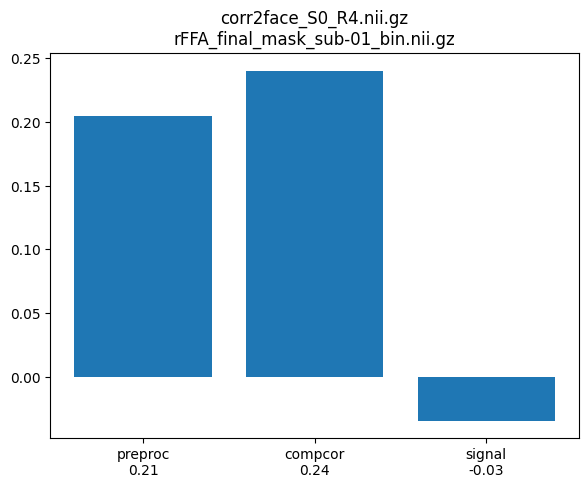

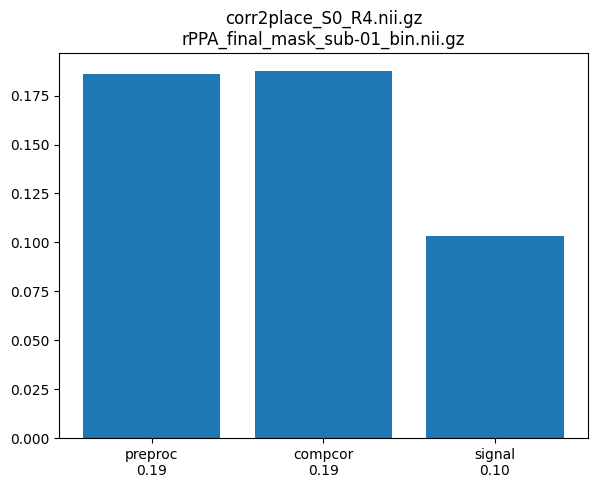

In [ ]:
if run_post_analyses==True:
    for analysis_spec_corr in correlation_analyses:
        deepcor.run_correlation_analysis_from_spec(analysis_spec_corr,epi,compcor,signals_averaged,gm)
plt.show()

saved as: ../Data/DeepCor-Outputs/test-advanced/DeepCor-Forrest-S0-R4-cvae_v2/contrast_face_0_R4_preproc.nii.gz
saved as: ../Data/DeepCor-Outputs/test-advanced/DeepCor-Forrest-S0-R4-cvae_v2/contrast_face_0_R4_compcor.nii.gz
saved as: ../Data/DeepCor-Outputs/test-advanced/DeepCor-Forrest-S0-R4-cvae_v2/contrast_face_0_R4_deepcor.nii.gz
saved as: ../Data/DeepCor-Outputs/test-advanced/DeepCor-Forrest-S0-R4-cvae_v2/contrast_place_S0_R4_preproc.nii.gz
saved as: ../Data/DeepCor-Outputs/test-advanced/DeepCor-Forrest-S0-R4-cvae_v2/contrast_place_S0_R4_compcor.nii.gz
saved as: ../Data/DeepCor-Outputs/test-advanced/DeepCor-Forrest-S0-R4-cvae_v2/contrast_place_S0_R4_deepcor.nii.gz


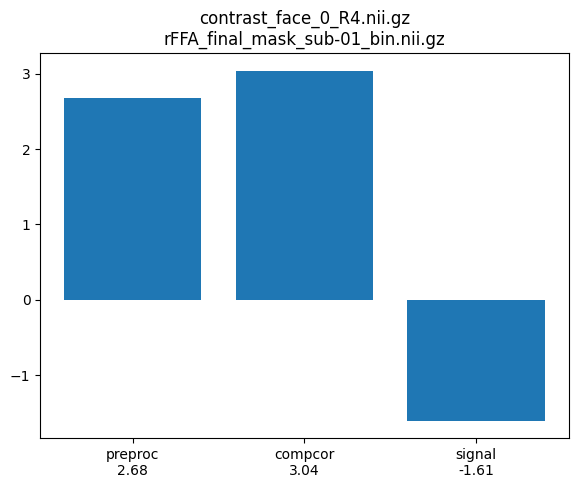

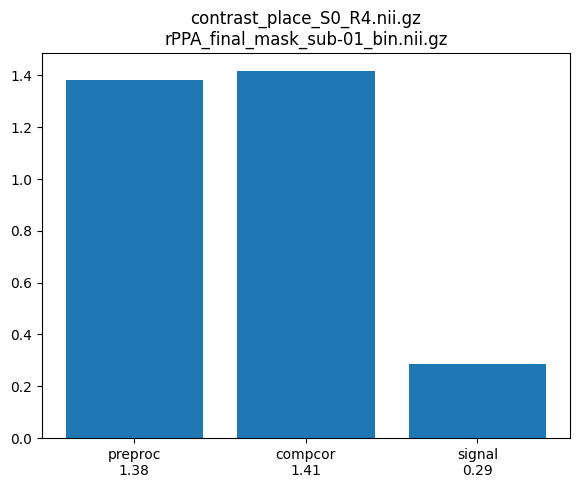

In [ ]:
if run_post_analyses==True:
    for analysis_spec_con in contrast_analyses:
        deepcor.run_contrast_analysis_from_spec(analysis_spec_con,epi,compcor,signals_averaged,gm)
plt.show()

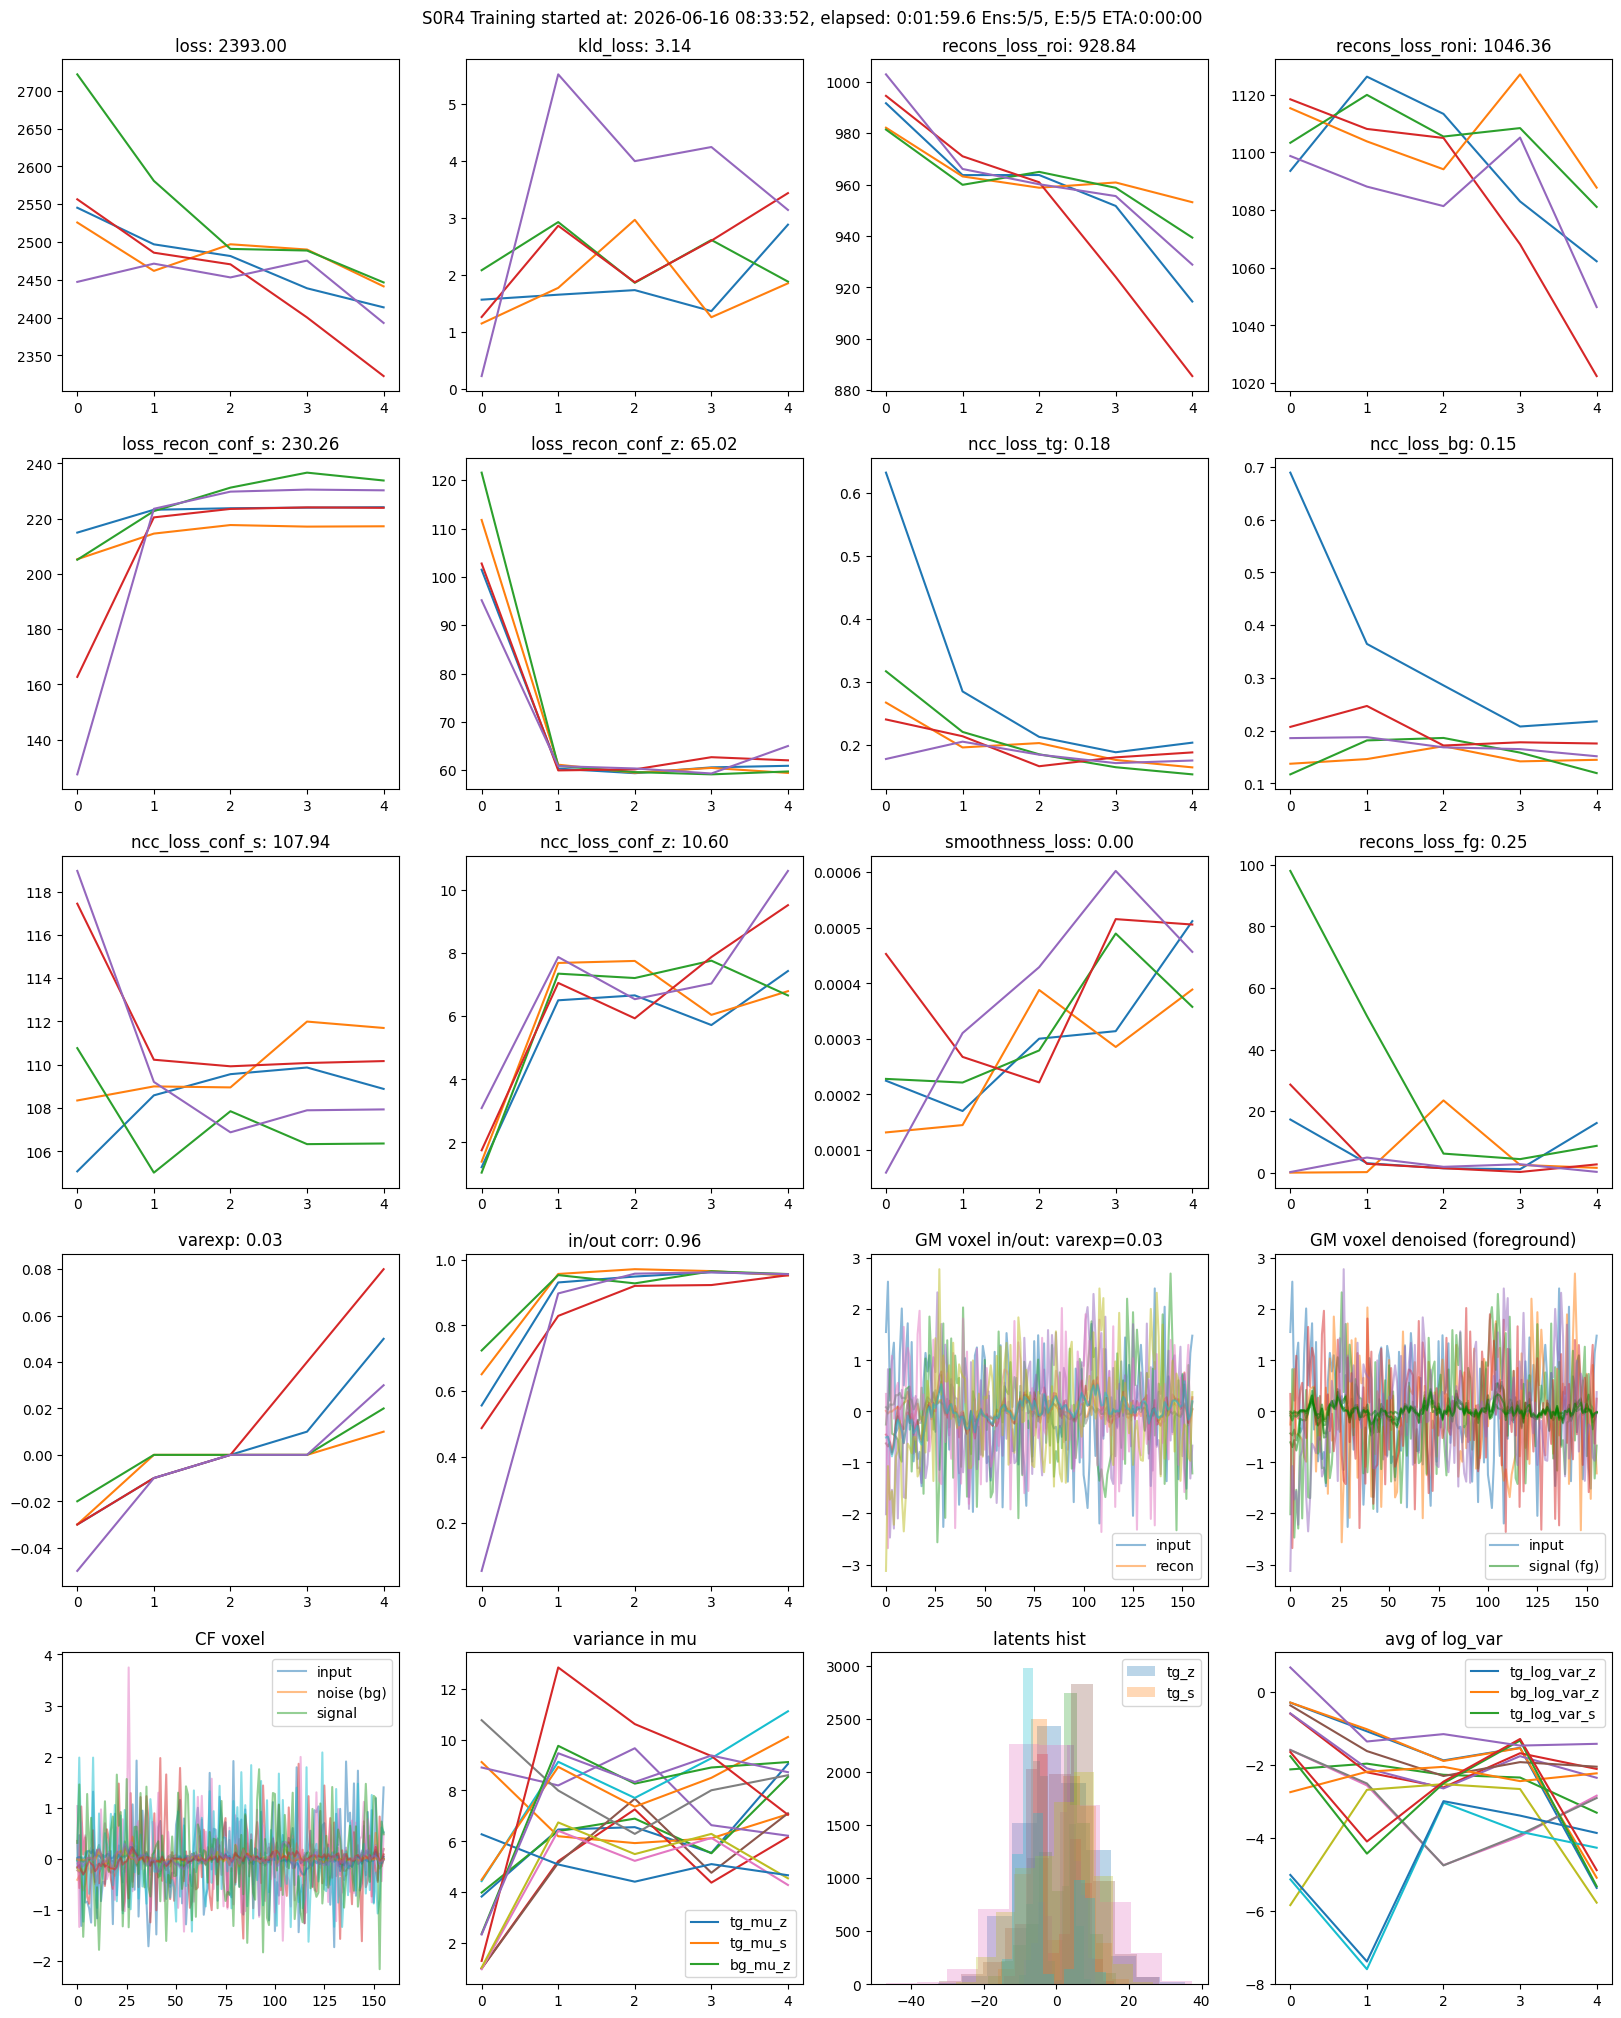

In [ ]:
import warnings
warnings.filterwarnings("ignore")
tracks = [deepcor.data.load_pickle(track_file) for track_file in track_files]
this_fig = None
for this_track in tracks:
    try:
        this_fig = deepcor.visualization.show_dahsboard_v2_marimo(this_track, fig=this_fig,save_fig=False)
    except Exception as e:
        print(f'bad track: {e}')
if this_fig is not None:
    this_fig.savefig(os.path.join(output_dir, f'dashboard_S{s}_R{r}.png'), dpi=100, bbox_inches='tight')
plt.show()